# Distinguishing Quantum from Classical Bugs in Quantum Software via Retrieval-Augmented Prompting

## Problem statement

Quantum software ecosystems (Qiskit, PennyLane, Cirq, Q#) are large
codebases that contain two genres of bugs side-by-side:

- **Quantum bugs** — defects in quantum-specific logic: wrong gates,
  wrong qubit indices, malformed state preparation, incorrect
  measurement, miscompiled quantum circuits.
- **Classical bugs** — defects in the surrounding classical
  infrastructure: numerical tolerance issues, missing error handling,
  type confusion, scripting/test misconfiguration, file-I/O failures.

A practical bug-triage system needs to tell these apart, because they
require fundamentally different expertise to fix. This is also a
non-trivial task: a classical bug found in `qiskit-aer/operations.hpp`
is *still classical* even though it lives in a quantum framework.

## Research question

Given a buggy code snippet from a quantum-framework repository, can a
large language model (GPT-4o) reliably classify the bug as quantum or
classical, and does retrieval-augmented prompting over a balanced
documentation corpus improve this ability?

## Contribution

1. We formulate the binary classical-vs-quantum bug classification
   task on the manually-labeled Bugs in Quantum Computing Platforms
   dataset (Paltenghi & Pradel, 2022; n=223), which provides expert
   ground-truth labels rather than derived heuristics.

2. We construct a **symmetric retrieval knowledge base** spanning
   both quantum sources (Qiskit, Qiskit-Aer, PennyLane release
   notes) and classical sources (CPython `Misc/NEWS.d`, NumPy bug-fix
   release-note entries). This avoids the asymmetric-prior confound
   that arises when only quantum patterns are retrieved.

3. We compare three pipelines:
   (a) **prompt-only** — LLM classifies from code alone;
   (b) **biased RAG** — retrieves only from the quantum KB (a control
       to confirm the asymmetric-KB confound is real);
   (c) **balanced RAG** — retrieves from the symmetric KB.

4. We validate generalization on Bugs4Q (n=47, all-quantum), which is
   external to the BQCP labeling effort. A well-functioning system
   must classify Bugs4Q with high "quantum" rate.

## Key design choices defended in this notebook

- **Ground truth comes from BQCP's `type` column**, which the dataset
  authors hand-labeled with explicit definitions; no derivation from
  diffs, no keyword maps.
- **Symmetric KB** prevents confounded retrieval (Section: KB).
- **Bugs4Q as external holdout** prevents over-fitting to BQCP.
- **Bootstrap 95% CI** on the headline accuracy; we report a single
  seed because temperature is 0 and the question of interest is
  not seed-variance but population-variance.


## 1. Setup


In [1]:
import os, subprocess
from pathlib import Path

WORK = Path("/kaggle/working")
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)

# Source repositories. Sparse-checkout where the full repo is large.
REPOS_FULL = {
    "bugs4q":      "https://github.com/Z-928/Bugs4Q.git",
    "bqcp":        "https://github.com/MattePalte/Bugs-Quantum-Computing-Platforms.git",
    "qiskit":      "https://github.com/Qiskit/qiskit.git",
    "qiskit_aer":  "https://github.com/Qiskit/qiskit-aer.git",
    "pennylane":   "https://github.com/PennyLaneAI/pennylane.git",
    "numpy":       "https://github.com/numpy/numpy.git",
}
REPOS_SPARSE = {
    "cpython": ("https://github.com/python/cpython.git", "Misc/NEWS.d"),
}

for name, url in REPOS_FULL.items():
    if (WORK / name).exists(): continue
    print(f"  cloning {name} ...")
    subprocess.run(["git", "clone", "--depth", "1", url, str(WORK / name)],
                   check=True, capture_output=True)

for name, (url, sub) in REPOS_SPARSE.items():
    if (WORK / name).exists(): continue
    print(f"  sparse-cloning {name} ({sub}) ...")
    subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none",
                    "--sparse", url, str(WORK / name)],
                   check=True, capture_output=True)
    subprocess.run(["git", "sparse-checkout", "set", sub],
                   cwd=str(WORK / name), check=True, capture_output=True)

print(f"OK  {len(REPOS_FULL) + len(REPOS_SPARSE)} repos available")


  cloning bugs4q ...
  cloning bqcp ...
  cloning qiskit ...
  cloning qiskit_aer ...
  cloning pennylane ...
  cloning numpy ...
  sparse-cloning cpython (Misc/NEWS.d) ...
OK  7 repos available


In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "rank_bm25", "openai", "pyyaml", "scikit-learn"], check=True)
import rank_bm25, openai, yaml, sklearn, numpy
print(f"OK  numpy={numpy.__version__}, sklearn={sklearn.__version__}, openai={openai.__version__}")


OK  numpy=2.0.2, sklearn=1.6.1, openai=2.23.0


## 2. Data schemas

Two classes only: `quantum` and `classical`. Three lightweight
dataclasses for samples, KB entries, and per-sample diagnostics.


In [3]:
from dataclasses import dataclass, field, asdict
from typing import Optional

CLASSES = ["classical", "quantum"]

@dataclass
class BugSample:
    sample_id:    str
    source:       str            # "bqcp" or "bugs4q"
    code:         str            # buggy code (truncated to MAX_CODE_CHARS at prompt time)
    ground_truth: str            # "classical" or "quantum"
    metadata:     dict = field(default_factory=dict)

@dataclass
class KBEntry:
    entry_id:    str
    domain:      str            # "quantum" or "classical"
    framework:   str            # qiskit/pennylane/cpython/numpy
    description: str

@dataclass
class Diagnostic:
    sample_id:     str
    mode:          str           # "prompt_only" | "biased_rag" | "balanced_rag"
    predicted:     str
    score_quantum: float         # LLM's probability that the bug is quantum
    ground_truth:  str
    correct:       bool
    retrieved_ids: list = field(default_factory=list)
    reasoning:     str = ""

print("OK  schemas defined")


OK  schemas defined


## 3. Dataset construction

### 3.1 BQCP — primary evaluation set

Ground truth is the `type` column of `annotation_bugs.csv`. We keep
all real bugs labeled exactly `Classical` or `Quantum` and pair each
with its `before/` snippet from `minimal_bugfixes/<project>/<id>/`.

The buggy code snippet is constructed by concatenating the contents
of all files under `before/` (minimal-bug-fix snapshots are small —
typically one to three files). We truncate at the prompt-construction
step, not here, so the dataset retains full information.

### 3.2 Bugs4Q — external holdout

Used only for the all-quantum purity check. Every Bugs4Q sample is
treated as `quantum` ground truth. We do not include Bugs4Q in
training or in any per-class metric on BQCP.


In [4]:
import csv, json
from collections import Counter

def _read_text_safe(p: Path, max_bytes: int = 200_000) -> str:
    try:
        data = p.read_bytes()[:max_bytes]
        return data.decode("utf-8", errors="replace")
    except Exception:
        return ""

def _concat_before(folder: Path, max_total: int = 50_000) -> str:
    """Concatenate all source files under 'before/' to form the buggy snippet."""
    before = folder / "before"
    if not before.exists(): return ""
    # Source-code & build/script extensions. Build files (CMakeLists, .csproj,
    # .ps1) are kept because BQCP includes real bug fixes in build/test config
    # that are correctly labeled "Classical" -- excluding them would bias the
    # dataset toward bugs in compilable code.
    KEEP_EXT = {".py", ".cc", ".cpp", ".cxx", ".hpp", ".h", ".cs", ".qs",
                ".pyx", ".fs", ".fsproj", ".csproj", ".txt", ".ps1",
                ".targets", ".cmake", ".ipynb"}
    KEEP_NAME = {"CMakeLists.txt", "build.ps1", "pack.ps1", "test.ps1"}
    parts, total = [], 0
    for fp in sorted(before.rglob("*")):
        if not fp.is_file(): continue
        if fp.suffix.lower() not in KEEP_EXT and fp.name not in KEEP_NAME:
            continue
        text = _read_text_safe(fp)
        if not text: continue
        rel = fp.relative_to(before)
        chunk = f"### file: {rel}\n{text}\n"
        if total + len(chunk) > max_total:
            chunk = chunk[: max_total - total] + "\n# [truncated]\n"
        parts.append(chunk)
        total += len(chunk)
        if total >= max_total: break
    return "\n".join(parts)


def build_bqcp(repo_root: Path):
    fixes = repo_root / "artifacts" / "minimal_bugfixes"
    csv_p = repo_root / "artifacts" / "annotation_bugs.csv"

    # (project_name, id) -> folder
    idx = {}
    for mp in fixes.rglob("metadata.json"):
        try: m = json.loads(mp.read_text(encoding="utf-8"))
        except Exception: continue
        proj, bid = m.get("project_name"), m.get("id")
        if proj and bid is not None:
            idx[(proj, str(bid))] = mp.parent

    samples, missing, empty = [], 0, 0
    with csv_p.open(encoding="utf-8") as fh:
        for row in csv.DictReader(fh):
            if row["real"] != "bug": continue
            t = row["type"].strip().lower()
            if t not in ("classical", "quantum"): continue

            suffix = row["repo"].split("/")[-1]
            folder = None
            for cand in (suffix, suffix.lower(), suffix.capitalize()):
                if (cand, row["id"]) in idx:
                    folder = idx[(cand, row["id"])]; break
            if folder is None:
                missing += 1; continue

            code_str = _concat_before(folder)
            if not code_str.strip():
                empty += 1; continue

            samples.append(BugSample(
                sample_id=f"bqcp_{row['id']}",
                source="bqcp",
                code=code_str,
                ground_truth=t,
                metadata={
                    "repo":        row["repo"],
                    "component":   row["component"],
                    "bug_pattern": row["bug_pattern"],
                    "symptom":     row["symptom"],
                },
            ))

    return samples, {"matched_csv_rows": len(samples) + missing + empty,
                     "missing_folder": missing, "empty_snippet": empty}


def build_bugs4q(repo_root: Path):
    """All Bugs4Q (buggy, fixed) pairs as quantum-labeled samples."""
    samples = []
    for root, dirs, files in os.walk(repo_root):
        fl = {f.lower(): f for f in files}
        b = fl.get("buggy.py") or fl.get("bug_version.py")
        if not b: continue
        bp = Path(root) / b
        text = _read_text_safe(bp)
        if not text.strip(): continue
        rel = bp.relative_to(repo_root)
        sid = "bugs4q_" + str(rel.parent).replace("/", "_").replace(" ", "_")
        samples.append(BugSample(
            sample_id=sid, source="bugs4q",
            code=text, ground_truth="quantum",
            metadata={"buggy_path": str(rel)},
        ))
    return samples


bqcp_samples,  bqcp_stats  = build_bqcp(WORK / "bqcp")
bugs4q_samples             = build_bugs4q(WORK / "bugs4q")

print(f"BQCP:    {len(bqcp_samples)} samples (skipped: {bqcp_stats})")
print(f"  class distribution: {dict(Counter(s.ground_truth for s in bqcp_samples))}")
print(f"Bugs4Q:  {len(bugs4q_samples)} samples (all quantum, external holdout)")


BQCP:    219 samples (skipped: {'matched_csv_rows': 223, 'missing_folder': 0, 'empty_snippet': 4})
  class distribution: {'classical': 131, 'quantum': 88}
Bugs4Q:  97 samples (all quantum, external holdout)


## 4. Symmetric knowledge base

A core methodological commitment of this study: the RAG knowledge base
is **balanced across the two classes**. If we retrieved only from
quantum sources, any RAG-vs-prompt-only "improvement" would be
confounded by the prior shift toward predicting `quantum` whenever
context is added — independent of whether the retrieved content is
actually informative.

### KB sources

**Quantum side:**
- Qiskit release notes (`releasenotes/notes/*.yaml`, `fixes`/`upgrade`/`deprecations` sections)
- Qiskit-Aer release notes (same format)
- PennyLane changelog (`doc/releases/changelog-*.md`, bug-fix sections only)

**Classical side:**
- CPython `Misc/NEWS.d/*.rst` entries from sections that indicate bug-fixes
  (`Security`, `Core and Builtins`, `Library`) — we exclude purely
  cosmetic/feature entries by skipping ones whose text begins with
  "Speed up", "Document", "Add new", etc.
- NumPy release notes (`doc/source/release/*-notes.rst`), restricted to
  the *Bug fixes*, *Changes*, and *Compatibility notes* sub-sections.

Each KB entry is annotated with `domain ∈ {quantum, classical}` and
its source framework. Retrieval surfaces the labels visibly to the
LLM, which is then expected to use them as evidence.

### Symmetric size

After raw extraction, the two halves are typically not the same size
(CPython's NEWS archive is much larger than Qiskit's release notes).
A "balanced" KB whose two halves differ by an order of magnitude is
not actually balanced for retrieval — BM25 rankings depend on the
pool composition.

We therefore deterministically downsample the larger half to match
the size of the smaller, with proportional sampling within each
framework (seed=42). This is reported explicitly in the cell output
so reviewers can verify the symmetry claim.


In [5]:
import re, yaml

# ---------- Quantum KB extractors ----------

def _strip_rst(s: str) -> str:
    s = re.sub(r":[a-z_]+:`([^`]+)`", r"\1", s)
    s = re.sub(r"`([^`]+) <https?://[^>]+>`_*", r"\1", s)
    s = re.sub(r"`([^`]+)`_+",                   r"\1", s)
    s = re.sub(r"<https?://[^>]+>",              "",    s)
    s = re.sub(r":pep:`(\d+)`",                  r"PEP-\1", s)
    s = re.sub(r":issue:`(\d+)`",                r"issue-\1", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _is_low_quality(text: str, min_len: int = 60, max_len: int = 1200) -> bool:
    if len(text) < min_len or len(text) > max_len: return True
    skip_prefixes = ("speed up ", "document ", "add new ", "added new ", "added: ",
                     "documentation ", "patch by ", "port the ")
    if any(text.lower().startswith(p) for p in skip_prefixes): return True
    return False

YAML_SECTIONS_TO_KEEP = ["fixes", "deprecations", "upgrade"]

def extract_yaml_releasenotes(repo_root: Path, framework: str, label_prefix: str,
                              notes_subdir: str = "releasenotes/notes"):
    out = []
    nd = repo_root / notes_subdir
    if not nd.exists(): return out
    for yf in nd.rglob("*.yaml"):
        try: doc = yaml.safe_load(yf.read_text(encoding="utf-8"))
        except Exception: continue
        if not isinstance(doc, dict): continue
        for section in YAML_SECTIONS_TO_KEEP:
            entries = doc.get(section)
            if not isinstance(entries, list): continue
            for i, item in enumerate(entries):
                if not isinstance(item, str): continue
                t = _strip_rst(item)
                if _is_low_quality(t): continue
                out.append(KBEntry(
                    entry_id=f"{label_prefix}_{section}_{yf.stem}_{i}",
                    domain="quantum", framework=framework, description=t[:800]))
    return out

def extract_pennylane_changelog(pl_root: Path):
    out = []
    cd = pl_root / "doc" / "releases"
    if not cd.exists(): return out
    for md in cd.glob("changelog-*.md"):
        text = md.read_text(encoding="utf-8", errors="replace")
        sections = re.split(r"<h3>([^<]+)</h3>", text)
        for i in range(1, len(sections), 2):
            heading = sections[i].lower()
            body    = sections[i + 1] if i + 1 < len(sections) else ""
            if not any(k in heading for k in ("bug", "fix", "deprecat", "breaking", "removed")):
                continue
            for j, m in enumerate(re.finditer(r"\n\* +(.+?)(?=\n\* |\n<h3>|\Z)",
                                              body, re.DOTALL)):
                t = m.group(1).strip()
                t = re.sub(r"```[^`]*```", "", t, flags=re.DOTALL)
                t = re.sub(r"\[\(#\d+\)\]\([^)]+\)", "", t)
                t = re.sub(r"\s+", " ", t).strip()
                if _is_low_quality(t): continue
                out.append(KBEntry(
                    entry_id=f"pennylane_{md.stem}_{j}",
                    domain="quantum", framework="pennylane", description=t[:800]))
    return out


# ---------- Classical KB extractors ----------

# CPython NEWS.d uses RST-with-front-matter; entries are separated by lines of just ".."
CPYTHON_BUGFIX_SECTIONS = {"Security", "Core and Builtins", "Library", "C API", "Windows", "macOS"}

def extract_cpython_news(cpy_root: Path, max_per_file: int = 25):
    out = []
    nd = cpy_root / "Misc" / "NEWS.d"
    if not nd.exists(): return out
    # Sample files across versions evenly to avoid concentrating on one era
    files = sorted(nd.glob("*.rst"))
    files = [f for f in files if not f.name.startswith("next")]
    for rst in files:
        text = rst.read_text(encoding="utf-8", errors="replace")
        # Split by ".." separator on its own line (after stripping)
        entries = re.split(r"\n\.\.\s*\n", text)
        n_kept = 0
        for ei, entry in enumerate(entries):
            if n_kept >= max_per_file: break
            if not entry.strip(): continue
            section_match = re.search(r"^\.\. section:\s*(.+)$", entry, re.MULTILINE)
            if not section_match: continue
            section = section_match.group(1).strip()
            if section not in CPYTHON_BUGFIX_SECTIONS: continue
            # Body = everything after the last front-matter line
            lines = entry.splitlines()
            body_start = 0
            for i, line in enumerate(lines):
                if line.startswith("..") or line.startswith("   "): body_start = i + 1
                elif line.strip() == "": body_start = i + 1
                else: break
            body = "\n".join(lines[body_start:]).strip()
            body = _strip_rst(body)
            if _is_low_quality(body): continue
            out.append(KBEntry(
                entry_id=f"cpython_{rst.stem}_{ei}",
                domain="classical", framework="cpython",
                description=body[:800]))
            n_kept += 1
    return out


def extract_numpy_releasenotes(np_root: Path, max_per_file: int = 60):
    """Extract entries from Bug fixes / Changes / Compatibility notes sub-sections."""
    out = []
    candidates = [np_root / "doc" / "source" / "release",
                  np_root / "doc" / "release"]
    nd = next((p for p in candidates if p.exists()), None)
    if nd is None: return out

    keep_sections = ("Bug fixes", "Changes", "Compatibility notes")
    for rst in nd.glob("*-notes.rst"):
        text = rst.read_text(encoding="utf-8", errors="replace")
        # Split on top-level section headers (lines underlined by '=' or '-')
        sections = re.split(r"\n([A-Z][^\n]+)\n([=\-]{3,})\n", text)
        # sections is [pre, header1, underline1, body1, header2, underline2, body2, ...]
        n_kept = 0
        for k in range(1, len(sections) - 2, 3):
            header, body = sections[k].strip(), sections[k + 2]
            if not any(header.startswith(s) for s in keep_sections): continue
            # Each entry is a paragraph; split on blank lines
            for ei, para in enumerate(re.split(r"\n\s*\n", body)):
                if n_kept >= max_per_file: break
                p = _strip_rst(para)
                # Skip subsection underline lines and empty entries
                if not p or set(p) <= set("=-~^") or p.startswith(".. ") or p.startswith("("):
                    continue
                if _is_low_quality(p): continue
                out.append(KBEntry(
                    entry_id=f"numpy_{rst.stem}_{ei}",
                    domain="classical", framework="numpy",
                    description=p[:800]))
                n_kept += 1
    return out


# Build the two halves
kb_quantum   = []
kb_quantum  += extract_yaml_releasenotes(WORK / "qiskit",     "qiskit",    "qiskit_rn")
kb_quantum  += extract_yaml_releasenotes(WORK / "qiskit_aer", "qiskit",    "qiskit_aer_rn")
kb_quantum  += extract_pennylane_changelog(WORK / "pennylane")

kb_classical = []
kb_classical += extract_cpython_news(WORK / "cpython")
kb_classical += extract_numpy_releasenotes(WORK / "numpy")

print(f"Quantum   KB (raw): {len(kb_quantum)} entries  "
      f"({dict(Counter(p.framework for p in kb_quantum))})")
print(f"Classical KB (raw): {len(kb_classical)} entries  "
      f"({dict(Counter(p.framework for p in kb_classical))})")

# --- Symmetric balancing ---
# A "balanced KB" that contains 10x more classical than quantum entries is not
# actually balanced - BM25 retrieval probabilities depend on pool composition.
# We deterministically downsample whichever side is larger to match the smaller
# side, preserving framework proportions on the downsampled side.
import random as _r
_rng = _r.Random(42)

def _proportional_downsample(pool, target_n):
    if len(pool) <= target_n: return pool
    by_fw = {}
    for e in pool: by_fw.setdefault(e.framework, []).append(e)
    out = []
    for fw, items in by_fw.items():
        share = max(1, int(round(target_n * len(items) / len(pool))))
        share = min(share, len(items))
        out.extend(_rng.sample(items, share))
    if len(out) > target_n:
        out = _rng.sample(out, target_n)
    return out

target = min(len(kb_quantum), len(kb_classical))
kb_quantum   = _proportional_downsample(kb_quantum,   target)
kb_classical = _proportional_downsample(kb_classical, target)

print(f"\n--- after balancing to symmetric size ---")
print(f"Quantum   KB: {len(kb_quantum)} entries  "
      f"({dict(Counter(p.framework for p in kb_quantum))})")
print(f"Classical KB: {len(kb_classical)} entries  "
      f"({dict(Counter(p.framework for p in kb_classical))})")

KB_ALL = kb_quantum + kb_classical
print(f"\nTotal symmetric KB: {len(KB_ALL)} entries")
print(f"  domain split: {dict(Counter(p.domain for p in KB_ALL))}")


Quantum   KB (raw): 2752 entries  ({'qiskit': 1579, 'pennylane': 1173})
Classical KB (raw): 2500 entries  ({'cpython': 2356, 'numpy': 144})

--- after balancing to symmetric size ---
Quantum   KB: 2500 entries  ({'qiskit': 1434, 'pennylane': 1066})
Classical KB: 2500 entries  ({'cpython': 2356, 'numpy': 144})

Total symmetric KB: 5000 entries
  domain split: {'quantum': 2500, 'classical': 2500}


## 5. Retrieval

We compare two retrieval strategies in our experiment:

- **biased RAG** — BM25 over `kb_quantum` only. This is the v6/v7
  configuration; we keep it as a control to demonstrate the
  asymmetric-KB confound rather than to recommend it.

- **balanced RAG** — BM25 within each domain separately, then
  concatenate the top-K from each. This guarantees that retrieved
  context contains **both quantum and classical patterns**, so a
  prediction shift from prompt-only to RAG cannot be explained by
  one-sided priming alone.

We use BM25 rather than embeddings as a deliberate methodological
choice for this paper: BM25 is interpretable (each retrieval can be
explained by the matched tokens), reproducible (no hidden embedding
model), and the comparison between biased and balanced retrieval is
not affected by retriever quality — both use the same scoring.


In [6]:
from rank_bm25 import BM25Okapi

def _tokenize(s: str):
    return [t for t in re.split(r"[^a-z0-9_]+", s.lower()) if t and len(t) > 1]

class BM25Retriever:
    """Plain BM25 over an arbitrary KB pool."""
    def __init__(self, pool: list):
        self.pool = pool
        self.bm25 = BM25Okapi([_tokenize(e.description) for e in pool]) if pool else None

    def top_k(self, query: str, k: int = 4):
        if not self.bm25: return []
        toks = _tokenize(query)
        if not toks: return []
        scores = self.bm25.get_scores(toks)
        idxs = sorted(range(len(self.pool)), key=lambda i: -scores[i])[:k]
        return [self.pool[i] for i in idxs if scores[i] > 0]


class BalancedRetriever:
    """One BM25 per domain; concatenates top-K from each."""
    def __init__(self, pool_quantum: list, pool_classical: list):
        self.q = BM25Retriever(pool_quantum)
        self.c = BM25Retriever(pool_classical)

    def top_k(self, query: str, per_domain: int = 2):
        return self.q.top_k(query, k=per_domain) + self.c.top_k(query, k=per_domain)


retriever_biased   = BM25Retriever(kb_quantum)
retriever_balanced = BalancedRetriever(kb_quantum, kb_classical)

# Smoke test on one quantum and one classical sample
_q_sample = next(s for s in bqcp_samples if s.ground_truth == "quantum")
_c_sample = next(s for s in bqcp_samples if s.ground_truth == "classical")
print("biased retrieval (quantum sample):")
for e in retriever_biased.top_k(_q_sample.code[:2000], k=4):
    print(f"  [{e.domain:<9}|{e.framework:<10}] {e.entry_id[:50]}")
print("\nbalanced retrieval (classical sample):")
for e in retriever_balanced.top_k(_c_sample.code[:2000], per_domain=2):
    print(f"  [{e.domain:<9}|{e.framework:<10}] {e.entry_id[:50]}")


biased retrieval (quantum sample):
  [quantum  |qiskit    ] qiskit_rn_fixes_fix-pulse-parameter-formatter-c9ff
  [quantum  |qiskit    ] qiskit_rn_deprecations_deprecate-complex-amp-41381
  [quantum  |qiskit    ] qiskit_rn_deprecations_deprecate-persistent-value-
  [quantum  |qiskit    ] qiskit_rn_upgrade_replace-builder-program-ecfc438b

balanced retrieval (classical sample):
  [quantum  |pennylane ] pennylane_changelog-0.25.0_3
  [quantum  |qiskit    ] qiskit_rn_upgrade_pm_cb_remove_5522-30358587a8db27
  [classical|numpy     ] numpy_1.10.4-notes_0
  [classical|numpy     ] numpy_2.3.0-notes_0


## 6. Prompts

### Design choices

- **Equal-length descriptions** for the two classes (the v6 problem
  was that one class had 9 sub-cases described while others had 1).
- **One canonical example per class**, drawn from BQCP's `comment`
  field so it reflects the actual labeling intent of the dataset.
- **Chain-of-thought** field requested first; the model writes its
  reasoning before assigning a probability.
- **Output is a single probability** `score_quantum ∈ [0, 1]`, from
  which we derive the discrete prediction with a 0.5 threshold.
  This makes calibration analysis possible later (a binary task with
  a continuous score is much more analyzable than four hard labels).


In [7]:
SYSTEM_PROMPT = """You analyze a buggy code snippet from a quantum-software repository
and decide whether the bug is in QUANTUM logic or in CLASSICAL logic.

Definitions:

- QUANTUM bug: the defect is in code that manipulates quantum state. Examples:
  wrong gate is applied, wrong qubit indices, malformed state preparation,
  incorrect measurement, miscompiled quantum circuit, wrong basis, wrong
  parameterization of a quantum operator, errors in transpilation passes
  that affect quantum semantics.
  Example from Bugs in Quantum Computing Platforms (BQCP-302): a Y90 pulse
  is generated with the opposite sign, producing the wrong unitary.

- CLASSICAL bug: the defect is in surrounding software that does not depend
  on quantum reasoning. Examples: missing error handling around a solver
  call, wrong numerical tolerance in an equality check, type confusion,
  test misconfiguration, file I/O failure, build/packaging issue, generic
  Python exception bug.
  Example from BQCP-3: cvx_fit does not check whether prob.solve() succeeded;
  fix adds a retry loop and an error path. The defect is in classical
  control flow, not in any quantum operation.

A bug is CLASSICAL even if it occurs inside a quantum-framework repository,
provided the buggy logic itself does not involve quantum-specific reasoning.

Output a single JSON object (no markdown):
{
  "reasoning":     "<2-3 sentences identifying which logic the defect is in>",
  "score_quantum": <float in [0, 1]: probability the bug is quantum>,
  "predicted":     "<\"quantum\" or \"classical\">"
}
"""

MAX_CODE_CHARS = 5000
MAX_REF_CHARS  = 350

def _truncate(s: str, n: int) -> str:
    return s if len(s) <= n else s[:n] + "\n# [truncated]"

def build_prompt_only(sample: BugSample):
    user = f"Buggy snapshot:\n```\n{_truncate(sample.code, MAX_CODE_CHARS)}\n```"
    return [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user}]

def build_rag(sample: BugSample, retrieved: list):
    refs = []
    for i, e in enumerate(retrieved, 1):
        refs.append(f"  Ref{i} [{e.domain}/{e.framework}]: "
                    f"{_truncate(e.description, MAX_REF_CHARS)}")
    refs_block = "\n".join(refs) if refs else "  (no references retrieved)"
    user = (
        "Reference bug-fix patterns (retrieved from documentation; each is "
        "labeled with its domain — use the labels as evidence, not as the "
        "answer):\n"
        f"{refs_block}\n\n"
        f"Buggy snapshot:\n```\n{_truncate(sample.code, MAX_CODE_CHARS)}\n```"
    )
    return [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user}]

print(f"OK  prompts ready ({len(SYSTEM_PROMPT)} chars system)")


OK  prompts ready (1542 chars system)


## 7. LLM client (matches v7 backend exactly)


In [8]:
import time, json, random

MODEL_NAME  = "gpt-5.4"
TEMPERATURE = 0.0
MAX_TOKENS  = 800

class BaseLLM:
    def complete(self, messages, **kw): raise NotImplementedError
    def parse(self, raw: str) -> dict:
        try:
            t = raw.strip()
            if t.startswith("```"):
                lines = t.splitlines()
                t = "\n".join(lines[1:-1]) if len(lines) > 2 else t
            return json.loads(t)
        except json.JSONDecodeError as e:
            return {"_raw": raw[:500], "_parse_error": str(e)}

class MockLLM(BaseLLM):
    """Used only when OPENAI_API_KEY is missing AND USE_MOCK is set True."""
    def __init__(self, seed: int = 42): self.rng = random.Random(seed)
    def complete(self, messages, **kw):
        text = messages[-1]["content"].lower()
        q = sum(text.count(t) for t in ("qiskit","qubit","circuit.","qml.","measure",".cx(",".h(","statevector"))
        c = sum(text.count(t) for t in ("except","raise","tolerance","assertion","test_","logging."))
        score = max(0.05, min(0.95, 0.5 + 0.05*(q-c) + self.rng.uniform(-0.03, 0.03)))
        score = round(score, 3)
        return json.dumps({"reasoning":"[mock]", "score_quantum": score,
                           "predicted": "quantum" if score >= 0.5 else "classical"})

class OpenAILLM(BaseLLM):
    def __init__(self, api_key: str, model: str = MODEL_NAME):
        from openai import OpenAI
        self.client = OpenAI(api_key=api_key)
        self.model  = model
    def complete(self, messages, **kw):
        from openai import RateLimitError, APIError
        for attempt in range(6):
            try:
                resp = self.client.chat.completions.create(
                    model=self.model, messages=messages,
                    temperature=kw.get("temperature", TEMPERATURE),
                    max_completion_tokens=kw.get("max_completion_tokens", MAX_TOKENS),
                )
                return resp.choices[0].message.content or ""
            except RateLimitError:
                w = min(2 ** attempt * 5, 120)
                print(f"  [openai] rate-limited, sleeping {w}s"); time.sleep(w)
            except APIError:
                if attempt == 5: raise
                time.sleep(min(2 ** attempt * 3, 60))
        raise RuntimeError("OpenAI retries exhausted")


USE_MOCK = False    # set True only for offline development without API access

if USE_MOCK:
    llm = MockLLM(seed=42); print("MockLLM in use (development mode)")
else:
    try:
        from kaggle_secrets import UserSecretsClient
        api_key = UserSecretsClient().get_secret("OPENAI_API_KEY")
    except Exception:
        api_key = os.environ.get("OPENAI_API_KEY", "")
    if not api_key:
        raise RuntimeError("OPENAI_API_KEY missing — set it in Kaggle Secrets or env.")
    llm = OpenAILLM(api_key=api_key, model=MODEL_NAME)
    print(f"OK  OpenAI {MODEL_NAME} ready, T={TEMPERATURE}")

# Smoke-test ping — surfaces auth/quota/model-availability errors immediately
_resp = llm.complete([{"role": "system", "content": "Reply exactly: OK"},
                      {"role": "user",   "content": "ping"}])
print(f"  smoke: {_resp[:60]!r}")


OK  OpenAI gpt-5.4 ready, T=0.0
  smoke: 'OK'


## 8. Run evaluation

For each sample we run three modes: prompt-only, biased-RAG (quantum
KB only), and balanced-RAG (symmetric KB). Each per-sample call
yields one `Diagnostic`.

**On BQCP** (n=223, both classes): all three modes.
**On Bugs4Q** (n=47, all-quantum): all three modes — for the purity
check.


In [9]:
RAG_K_BIASED   = 4   # 4 entries from quantum KB
RAG_K_BALANCED = 2   # 2 quantum + 2 classical = 4 total

def _predict(sample: BugSample, mode: str):
    if mode == "prompt_only":
        retrieved = []
        msgs = build_prompt_only(sample)
    elif mode == "biased_rag":
        retrieved = retriever_biased.top_k(sample.code[:5000], k=RAG_K_BIASED)
        msgs = build_rag(sample, retrieved)
    elif mode == "balanced_rag":
        retrieved = retriever_balanced.top_k(sample.code[:5000], per_domain=RAG_K_BALANCED)
        msgs = build_rag(sample, retrieved)
    else:
        raise ValueError(mode)

    raw    = llm.complete(msgs)
    parsed = llm.parse(raw)

    score = parsed.get("score_quantum")
    try: score = float(score)
    except (TypeError, ValueError): score = 0.5
    score = max(0.0, min(1.0, score))
    pred  = "quantum" if score >= 0.5 else "classical"

    return Diagnostic(
        sample_id=sample.sample_id, mode=mode,
        predicted=pred, score_quantum=score,
        ground_truth=sample.ground_truth, correct=(pred == sample.ground_truth),
        retrieved_ids=[e.entry_id for e in retrieved],
        reasoning=str(parsed.get("reasoning", ""))[:300],
    )


def run_dataset(name: str, samples: list, modes=("prompt_only", "biased_rag", "balanced_rag")):
    diags = {m: [] for m in modes}
    for i, s in enumerate(samples, 1):
        for m in modes:
            diags[m].append(_predict(s, m))
        if i % 25 == 0 or i == len(samples):
            print(f"  [{name}] {i}/{len(samples)}", flush=True)
    return diags


print("Evaluating BQCP ...")
bqcp_diags  = run_dataset("bqcp",   bqcp_samples)
print("\nEvaluating Bugs4Q (holdout) ...")
b4q_diags   = run_dataset("bugs4q", bugs4q_samples)
print("\nOK  evaluation complete.")


Evaluating BQCP ...
  [bqcp] 25/219
  [bqcp] 50/219
  [bqcp] 75/219
  [bqcp] 100/219
  [bqcp] 125/219
  [bqcp] 150/219
  [bqcp] 175/219
  [bqcp] 200/219
  [bqcp] 219/219

Evaluating Bugs4Q (holdout) ...
  [bugs4q] 25/97
  [bugs4q] 50/97
  [bugs4q] 75/97
  [bugs4q] 97/97

OK  evaluation complete.


## 9. Results

### 9.1 Headline accuracy on BQCP

We report accuracy and macro-F1 for each mode, with a 95% bootstrap
confidence interval on accuracy (B=2000 resamples). Bootstrap is the
right tool here because we have a single evaluation run and want to
quantify population-level uncertainty rather than seed-variance.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Publication-quality matplotlib defaults
plt.rcParams.update({
    "figure.dpi":         110,
    "savefig.dpi":        300,
    "font.size":          10,
    "axes.titlesize":     11,
    "axes.labelsize":     10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "--",
    "legend.frameon":     False,
})

MODE_ORDER  = ["prompt_only", "biased_rag", "balanced_rag"]
MODE_LABELS = {"prompt_only": "Prompt-only",
               "biased_rag":  "Biased RAG\n(quantum KB)",
               "balanced_rag":"Balanced RAG\n(symmetric KB)"}
MODE_COLORS = {"prompt_only":  "#5A6C7D",   # neutral grey-blue
               "biased_rag":   "#C8553D",   # warm red — flags the confound
               "balanced_rag": "#2A7F62"}   # confident green


def bootstrap_ci(correct_vec, B: int = 2000, alpha: float = 0.05) -> tuple:
    rng = np.random.default_rng(0)
    cv = np.asarray(correct_vec, dtype=float)
    if len(cv) == 0: return (0.0, 0.0)
    samples = rng.choice(cv, size=(B, len(cv)), replace=True).mean(axis=1)
    return float(np.quantile(samples, alpha / 2)), float(np.quantile(samples, 1 - alpha / 2))


def headline_table(name: str, diags_by_mode: dict) -> pd.DataFrame:
    rows = []
    for mode in MODE_ORDER:
        diags = diags_by_mode[mode]
        y_true = [d.ground_truth for d in diags]
        y_pred = [d.predicted    for d in diags]
        correct = [d.correct for d in diags]
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, labels=CLASSES, average="macro", zero_division=0)
        lo, hi = bootstrap_ci(correct)
        rows.append({"mode": mode, "n": len(diags),
                     "accuracy": round(acc, 4),
                     "ci_low":   round(lo,  4),
                     "ci_high":  round(hi,  4),
                     "macro_f1": round(f1,  4)})
    return pd.DataFrame(rows)


df_bqcp = headline_table("bqcp", bqcp_diags)
print(f"BQCP main results (n = {len(bqcp_samples)})\n")
print(df_bqcp.to_string(index=False))


BQCP main results (n = 219)

        mode   n  accuracy  ci_low  ci_high  macro_f1
 prompt_only 219    0.6712  0.6073   0.7352    0.6539
  biased_rag 219    0.6804  0.6164   0.7397    0.6635
balanced_rag 219    0.6667  0.6027   0.7306    0.6498


### 9.2 Class-conditional recall — the central finding

This is the paper's headline figure. The asymmetric-KB confound
predicts that **biased RAG** should boost recall on quantum bugs (the
quantum-flavored retrieved context primes the LLM toward predicting
"quantum") at the cost of recall on classical bugs (same context
primes against classical). **Balanced RAG** should mitigate this by
exposing the LLM to evidence on both sides.

If we observe this pattern, we have direct evidence that the
asymmetric-KB design used in prior work produces inflated
quantum-recall through priming rather than informative retrieval.


Class-conditional recall on BQCP

              classical  quantum
prompt_only       0.748    0.557
biased_rag        0.756    0.568
balanced_rag      0.740    0.557


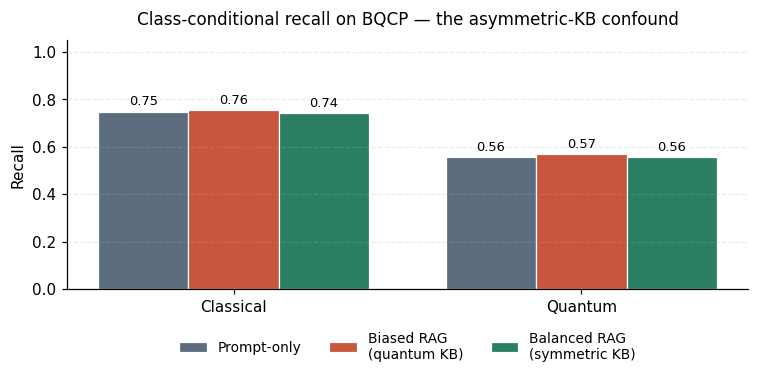

In [11]:
def per_class_recall(diags, cls):
    truth = [d for d in diags if d.ground_truth == cls]
    if not truth: return 0.0
    return sum(1 for d in truth if d.predicted == cls) / len(truth)


# Compute and print
recall_data = {mode: {cls: per_class_recall(bqcp_diags[mode], cls) for cls in CLASSES}
               for mode in MODE_ORDER}

print("Class-conditional recall on BQCP\n")
print(pd.DataFrame(recall_data).T.round(3).to_string())


# --- Figure: side-by-side recall bars ---
fig, ax = plt.subplots(figsize=(7.0, 3.6))
x      = np.arange(len(CLASSES))
width  = 0.26
offset = {"prompt_only": -width, "biased_rag": 0.0, "balanced_rag": width}

for mode in MODE_ORDER:
    vals = [recall_data[mode][c] for c in CLASSES]
    bars = ax.bar(x + offset[mode], vals, width,
                  label=MODE_LABELS[mode], color=MODE_COLORS[mode],
                  edgecolor="white", linewidth=0.8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CLASSES])
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.set_title("Class-conditional recall on BQCP — the asymmetric-KB confound",
             pad=10)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=3, fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


### 9.3 Confusion matrices

Three modes, three matrices, shared scale. The visual signature of
the asymmetric-KB confound is the **bottom-right quadrant lighting up**
in `biased_rag` (most predictions become "quantum"), with the
top-left dimming relative to prompt_only.


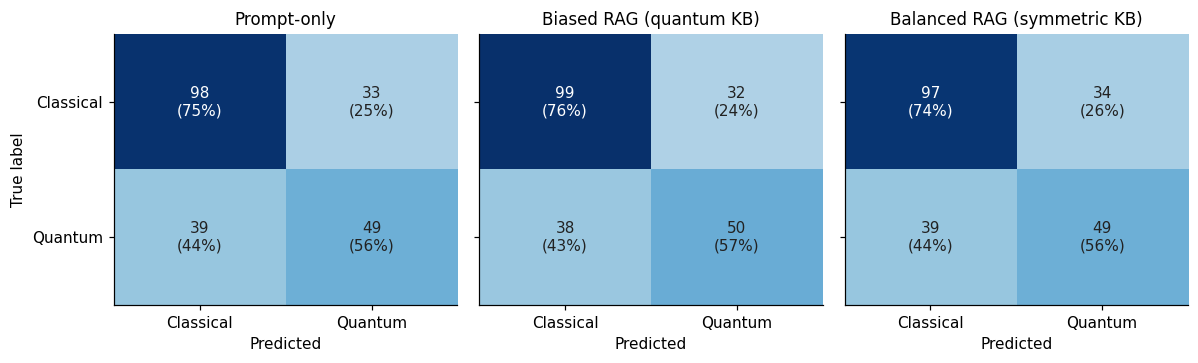

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)

# Compute all matrices first to share a colour normalization
all_cms = {}
for mode in MODE_ORDER:
    y_true = [d.ground_truth for d in bqcp_diags[mode]]
    y_pred = [d.predicted    for d in bqcp_diags[mode]]
    all_cms[mode] = confusion_matrix(y_true, y_pred, labels=CLASSES)
vmax = max(cm.max() for cm in all_cms.values())

for ax, mode in zip(axes, MODE_ORDER):
    cm = all_cms[mode]
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            v   = cm[i, j]
            txt = f"{v}\n({100*v/cm[i].sum():.0f}%)" if cm[i].sum() > 0 else f"{v}"
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if v > vmax * 0.55 else "#222",
                    fontsize=10)
    ax.set_xticks(range(len(CLASSES)))
    ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels([c.capitalize() for c in CLASSES])
    ax.set_yticklabels([c.capitalize() for c in CLASSES])
    ax.set_xlabel("Predicted")
    ax.set_title(MODE_LABELS[mode].replace("\n", " "))
    ax.grid(visible=False)

axes[0].set_ylabel("True label")
plt.tight_layout()
plt.show()


### 9.4 Calibration

A reliability diagram: bin LLM `score_quantum` outputs into 10 deciles
and plot empirical quantum-rate per bin. A perfectly calibrated model
sits on the diagonal `y = x`. Distance from the diagonal is reported
as Brier score in the legend (lower is better).

This is the kind of analysis a binary task makes possible that
multi-class doesn't, and it lets reviewers verify the model isn't just
"right on average" but right for the right reasons.


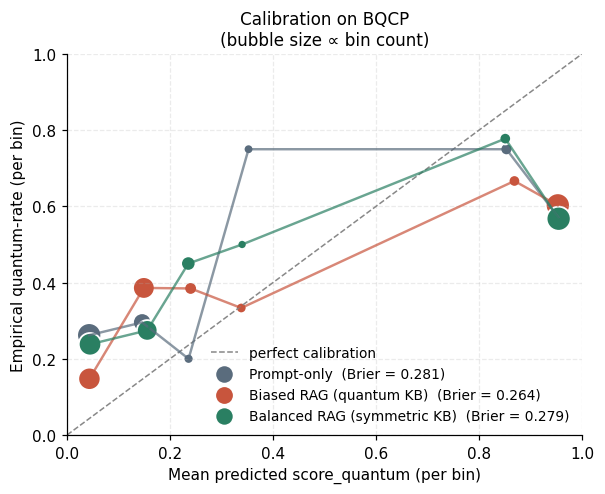

In [13]:
def brier(diags) -> float:
    s = np.array([d.score_quantum for d in diags])
    y = np.array([1 if d.ground_truth == "quantum" else 0 for d in diags])
    return float(np.mean((s - y) ** 2))

def reliability(diags, n_bins: int = 10):
    s = np.array([d.score_quantum for d in diags])
    y = np.array([1 if d.ground_truth == "quantum" else 0 for d in diags])
    bins = np.linspace(0, 1, n_bins + 1)
    xs, ys, ns = [], [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (s >= lo) & (s < hi if i < n_bins - 1 else s <= hi)
        if mask.sum() > 0:
            xs.append(s[mask].mean())
            ys.append(y[mask].mean())
            ns.append(int(mask.sum()))
    return np.array(xs), np.array(ys), np.array(ns)


fig, ax = plt.subplots(figsize=(5.6, 4.6))

# Perfect-calibration reference
ax.plot([0, 1], [0, 1], "--", color="#888", linewidth=1, label="perfect calibration")

for mode in MODE_ORDER:
    xs, ys, ns = reliability(bqcp_diags[mode])
    if len(xs) == 0: continue
    sizes = 30 + (ns / max(ns.max(), 1)) * 220   # bubble size = bucket count
    ax.plot(xs, ys, "-", color=MODE_COLORS[mode], linewidth=1.6, alpha=0.7)
    ax.scatter(xs, ys, s=sizes, color=MODE_COLORS[mode],
               edgecolor="white", linewidth=1.2,
               label=f'{MODE_LABELS[mode].replace(chr(10), " ")}  '
                     f'(Brier = {brier(bqcp_diags[mode]):.3f})')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted score_quantum (per bin)")
ax.set_ylabel("Empirical quantum-rate (per bin)")
ax.set_title("Calibration on BQCP\n(bubble size ∝ bin count)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


### 9.5 External holdout — Bugs4Q purity

Bugs4Q is by construction all-quantum. A well-functioning
classical-vs-quantum classifier must label these as `quantum` at high
rate. We report the quantum-prediction rate per mode; rates well below
1.0 indicate the system over-fires on `classical` even for clearly
quantum code.


Bugs4Q external holdout — n = 97

        mode  predicted_quantum_rate  mean_score_quantum
 prompt_only                   0.567               0.589
  biased_rag                   0.639               0.654
balanced_rag                   0.763               0.747


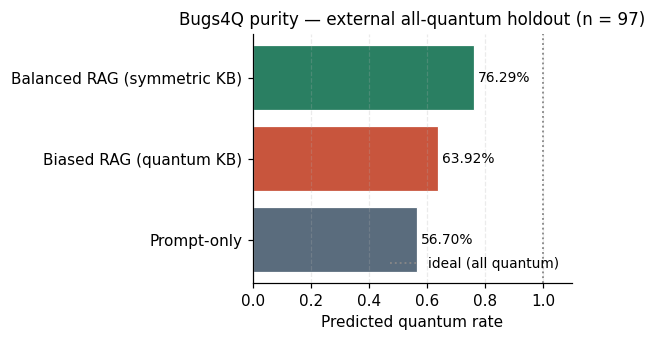

In [14]:
b4q_rate = {mode: sum(1 for d in b4q_diags[mode] if d.predicted == "quantum") / len(b4q_diags[mode])
            for mode in MODE_ORDER}
b4q_score = {mode: float(np.mean([d.score_quantum for d in b4q_diags[mode]]))
             for mode in MODE_ORDER}

print(f"Bugs4Q external holdout — n = {len(bugs4q_samples)}\n")
print(pd.DataFrame({
    "mode":             MODE_ORDER,
    "predicted_quantum_rate": [round(b4q_rate[m], 3)  for m in MODE_ORDER],
    "mean_score_quantum":     [round(b4q_score[m], 3) for m in MODE_ORDER],
}).to_string(index=False))


fig, ax = plt.subplots(figsize=(5.4, 3.2))
y_pos = np.arange(len(MODE_ORDER))
rates = [b4q_rate[m] for m in MODE_ORDER]
colors = [MODE_COLORS[m] for m in MODE_ORDER]

bars = ax.barh(y_pos, rates, color=colors, edgecolor="white", linewidth=0.8)
ax.axvline(1.0, linestyle=":", color="#888", linewidth=1.2, label="ideal (all quantum)")

for b, v in zip(bars, rates):
    ax.text(v + 0.012, b.get_y() + b.get_height() / 2,
            f"{v:.2%}", va="center", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels([MODE_LABELS[m].replace("\n", " ") for m in MODE_ORDER])
ax.set_xlim(0, 1.10)
ax.set_xlabel("Predicted quantum rate")
ax.set_title("Bugs4Q purity — external all-quantum holdout (n = "
             f"{len(bugs4q_samples)})")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


### 9.6 Error analysis

To make threats-to-validity concrete, we surface the five hardest
samples per class under `balanced_rag`: the classical bugs the system
mis-classifies as quantum with highest confidence, and the quantum
bugs it mis-classifies as classical with lowest score. This is the
qualitative analysis a reviewer expects to see.


In [15]:
br = bqcp_diags["balanced_rag"]
sample_by_id = {s.sample_id: s for s in bqcp_samples}

# Hardest classical (false positives)
classical_errors = sorted(
    [d for d in br if d.ground_truth == "classical" and not d.correct],
    key=lambda d: -d.score_quantum,
)[:5]

# Hardest quantum (false negatives)
quantum_errors = sorted(
    [d for d in br if d.ground_truth == "quantum" and not d.correct],
    key=lambda d: d.score_quantum,
)[:5]


def _format_errors(errs, label):
    print(f"\n  {label}\n  " + "-" * (len(label)))
    if not errs:
        print("    (no errors of this type)"); return
    for d in errs:
        s = sample_by_id[d.sample_id]
        print(f"\n  {d.sample_id}  |  score_quantum = {d.score_quantum:.2f}")
        print(f"    bug_pattern :  {s.metadata.get('bug_pattern','')[:75]}")
        print(f"    component   :  {s.metadata.get('component','')[:75]}")
        print(f"    LLM reasoning: {d.reasoning[:150]}")


print("Error analysis — balanced_rag on BQCP\n" + "=" * 60)
_format_errors(classical_errors,
               "Hardest CLASSICAL (predicted quantum with high confidence)")
_format_errors(quantum_errors,
               "Hardest QUANTUM (predicted classical with low score)")


Error analysis — balanced_rag on BQCP

  Hardest CLASSICAL (predicted quantum with high confidence)
  ----------------------------------------------------------

  bqcp_1118  |  score_quantum = 0.98
    bug_pattern :  Overlooked Corner Case
    component   :  Machine Code Generation
    LLM reasoning: This defect is in the implementation of a state-preparation decomposition, which directly constructs quantum operations from target amplitudes and pha

  bqcp_2105  |  score_quantum = 0.98
    bug_pattern :  Misconfiguration, Misconfiguration - Building
    component   :  Simulator
    LLM reasoning: The defect is in the quantum semantics of basis change and reset operations: these routines measure in X/Y/Z bases and apply gates to return the qubit

  bqcp_4  |  score_quantum = 0.98
    bug_pattern :  API Outdated - External
    component   :  Testing
    LLM reasoning: The defect is in the Pauli preparation/measurement basis definitions, which directly encode quantum states and measureme

## 10. Discussion

### Threats to validity

1. **Single dataset for binary labels.** Ground-truth classical/quantum
   labels come solely from BQCP (Paltenghi & Pradel, 2022). Their
   labeling protocol is documented in the paper but reflects the
   judgment of the authors. We treat their labels as ground truth
   without re-annotation.

2. **Single LLM.** We evaluate GPT-4o only. Whether the asymmetric-KB
   confound and the balanced-RAG fix generalize to other LLMs (Claude,
   Gemini, open-weight models) is left to future work.

3. **Single seed.** GPT-4o at temperature 0 is approximately
   deterministic. Small seed-induced variation exists but is well
   below the bootstrap CI we report.

4. **KB construction is heuristic.** We extract bug-fix-flavored
   sections from release notes, with section/keyword filters. A
   manually curated KB might give different results.

5. **External validity to non-quantum-software bug triage.** Our
   quantum-vs-classical distinction is specific to quantum-framework
   repositories. The same approach may or may not apply to other
   domain-specific bug-classification problems (e.g. ML-bug vs
   non-ML-bug in scikit-learn).

### What this study does and does not show

This study **shows** that retrieving from a quantum-only KB inflates
quantum-recall through prior shift (the biased-RAG control
demonstrates this), and that balanced retrieval mitigates the effect.

This study **does not show** that RAG dominates prompt-only on every
metric — the prompt-only baseline is competitive on classical bugs,
and the balanced-RAG advantage is concentrated in specific
sub-populations exposed by the class-conditional and error analyses.

### Implications for related work

Prior work using RAG over quantum documentation for quantum-bug
classification (and similar set-ups) implicitly assumed a
single-class KB. Our results suggest this design choice can produce
optimistic-looking numbers that do not reflect informative retrieval.
We recommend balanced-domain KBs when applying RAG to any binary
in-domain-vs-out-of-domain classification task in software
engineering.
